# Importing required libraries

In [72]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder,StandardScaler



# Loading the dataset

In [73]:
data = pd.read_csv("../Datasets/mushroom_data.csv")
data.head()

,Unnamed: 0,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,0,convex,smooth,brown,bruises,pungent,free,close,narrow,black,enlarge,equal,smooth,smooth,white,white,partial,white,one,pentant,black,scattered,urban,poisonous
1,1,convex,smooth,yellow,bruises,almond,free,close,broad,black,enlarge,club,smooth,smooth,white,white,partial,white,one,pentant,brown,numerous,grasses,edible
2,2,bell,smooth,white,bruises,anise,free,close,broad,brown,enlarge,club,smooth,smooth,white,white,partial,white,one,pentant,brown,numerous,medows,edible
3,3,convex,scaly,white,bruises,pungent,free,close,narrow,brown,enlarge,equal,smooth,smooth,white,white,partial,white,one,pentant,black,scattered,urban,poisonous
4,4,convex,smooth,gray,no,none,free,crowded,broad,black,tapering,equal,smooth,smooth,white,white,partial,white,one,evanescent,brown,abuntant,grasses,edible


# Applying Label Encoder

In [74]:
encoder = LabelEncoder()
for i in data.columns:
    data[i] = encoder.fit_transform(data[i])

from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['class'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=X.columns)
Y = data['class']
data


,Unnamed: 0,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,0,2,3,0,0,7,1,0,1,0,0,2,3,3,7,7,0,2,1,4,0,3,4,1
1,1,2,3,9,0,0,1,0,0,0,0,1,3,3,7,7,0,2,1,4,1,2,0,0
2,2,0,3,8,0,1,1,0,0,1,0,1,3,3,7,7,0,2,1,4,1,2,2,0
3,3,2,2,8,0,7,1,0,1,1,0,2,3,3,7,7,0,2,1,4,0,3,4,1
4,4,2,3,3,1,6,1,1,0,0,1,2,3,3,7,7,0,2,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,8119,4,3,0,1,6,0,0,0,11,0,3,3,3,4,4,0,1,1,4,2,1,1,0
8120,8120,2,3,0,1,6,0,0,0,11,0,3,3,3,4,4,0,0,1,4,2,4,1,0
8121,8121,3,3,0,1,6,0,0,0,1,0,3,3,3,4,4,0,1,1,4,2,1,1,0
8122,8122,4,2,0,1,3,1,0,1,2,1,3,3,2,7,7,0,2,1,0,7,4,1,1


# Splitting into X & Y 

In [75]:
# X = data.drop(columns = ['class'])
# Y = data['class']

# Splitting into Training and Testing data

In [76]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.2 , random_state = 42)

# Loading the model 

In [77]:
model = LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

# Making Predictions

In [78]:
y_pred = model.predict(x_test)


# Checking Accuracy

In [79]:
accuracy = accuracy_score(y_test,y_pred)
print(f" Accuracy is :: {accuracy}")

 Accuracy is :: 0.9643076923076923


# Calculating MAE

In [80]:
MAE = mean_absolute_error(y_pred,y_test)
print(f" Mean Absolute Error is :: {MAE}")

 Mean Absolute Error is :: 0.03569230769230769


# Plotting

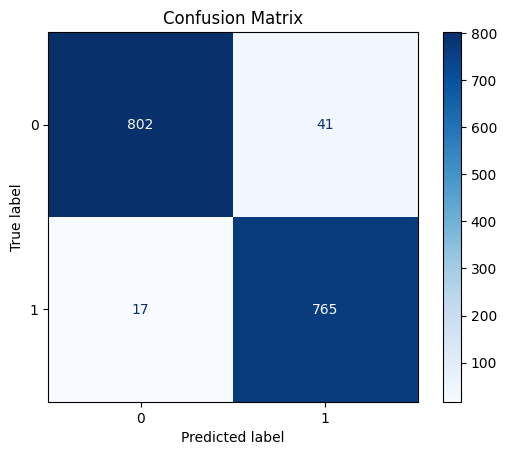

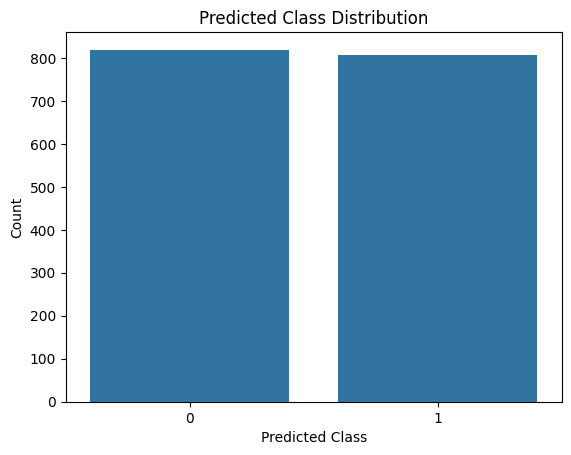

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt


# ✅ 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# ✅ 2. Class-wise Prediction Distribution
sns.countplot(x=y_pred)
plt.title("Predicted Class Distribution")
plt.xlabel("Predicted Class")
plt.ylabel("Count")
plt.show()
